In [1]:

# Analysis Plan
print("="*80)
print("ANALYSIS PLAN: GEV Shape Parameter Convergence for Riemann Zeta Function")
print("="*80)
print()
print("Research Question:")
print("Does ξ_zeta(N) converge towards 0 as N increases?")
print()
print("Step 1: Load previous results from N=10^5")
print(" - Load gev_fit_results.json")
print(" - Extract ξ_zeta(10^5) = -0.1365 with CI [-0.263, 0.015]")
print()
print("Step 2: Generate partial sum data for N=10^6")
print(" - Compute D_ζ(t; N=10^6) for t ∈ [1000, 10000]")
print(" - Use Kahan compensated summation for numerical precision")
print(" - Riemann zeta coefficients: a_n = 1 for all n")
print()
print("Step 3: Extract 100 block maxima from |D_ζ(t; N=10^6)|")
print(" - Divide time series into 100 blocks")
print(" - Compute maximum |D(t)| in each block")
print()
print("Step 4: Fit GEV distribution and estimate ξ_zeta(10^6)")
print(" - Use scipy.stats.genextreme")
print(" - Compute 95% bootstrap confidence interval")
print(" - Assess goodness-of-fit with KS test")
print()
print("Step 5: Compare N=10^6 vs N=10^5 results")
print(" - Test if |ξ_zeta(10^6)| < |ξ_zeta(10^5)|")
print(" - Compare confidence interval widths")
print(" - Assess convergence to 0")
print()
print("Statistical Methods:")
print(" - Extreme Value Theory (GEV distribution)")
print(" - Bootstrap resampling (10,000 iterations) for CI estimation")
print(" - Kolmogorov-Smirnov test for goodness-of-fit")
print()
print("Expected Computation:")
print(" - N=10^6 terms in partial sum")
print(" - ~9000 time points")
print(" - Computational cost ~10x higher than N=10^5")
print("="*80)


ANALYSIS PLAN: GEV Shape Parameter Convergence for Riemann Zeta Function

Research Question:
Does ξ_zeta(N) converge towards 0 as N increases?

Step 1: Load previous results from N=10^5
 - Load gev_fit_results.json
 - Extract ξ_zeta(10^5) = -0.1365 with CI [-0.263, 0.015]

Step 2: Generate partial sum data for N=10^6
 - Compute D_ζ(t; N=10^6) for t ∈ [1000, 10000]
 - Use Kahan compensated summation for numerical precision
 - Riemann zeta coefficients: a_n = 1 for all n

Step 3: Extract 100 block maxima from |D_ζ(t; N=10^6)|
 - Divide time series into 100 blocks
 - Compute maximum |D(t)| in each block

Step 4: Fit GEV distribution and estimate ξ_zeta(10^6)
 - Use scipy.stats.genextreme
 - Compute 95% bootstrap confidence interval
 - Assess goodness-of-fit with KS test

Step 5: Compare N=10^6 vs N=10^5 results
 - Test if |ξ_zeta(10^6)| < |ξ_zeta(10^5)|
 - Compare confidence interval widths
 - Assess convergence to 0

Statistical Methods:
 - Extreme Value Theory (GEV distribution)
 - Boot

In [2]:

import numpy as np
import json
from scipy import stats
import time

# Load previous N=10^5 results
with open('gev_fit_results.json', 'r') as f:
 previous_results = json.load(f)

print("Previous Results (N=10^5):")
print(f" ξ_zeta = {previous_results['zeta']['xi']:.6f}")
print(f" 95% CI: [{previous_results['zeta']['ci_xi'][0]:.6f}, {previous_results['zeta']['ci_xi'][1]:.6f}]")
print(f" μ = {previous_results['zeta']['mu']:.6f}")
print(f" σ = {previous_results['zeta']['sigma']:.6f}")
print(f" KS test p-value: {previous_results['zeta']['ks_pvalue']:.6f}")
print()
print(f"Previous analysis parameters:")
print(f" N = {previous_results['parameters']['N']}")
print(f" t-range: [{previous_results['parameters']['t_min']}, {previous_results['parameters']['t_max']}]")
print(f" Number of blocks: {previous_results['parameters']['n_blocks']}")
print(f" Number of time points: {previous_results['parameters']['n_points']}")


Previous Results (N=10^5):
 ξ_zeta = -0.136484
 95% CI: [-0.263474, 0.015299]
 μ = 10.439755
 σ = 1.732331
 KS test p-value: 0.819182

Previous analysis parameters:
 N = 100000
 t-range: [1000, 10000]
 Number of blocks: 100
 Number of time points: 9000


In [3]:

def kahan_sum(values):
 """
 Compute sum with Kahan compensated summation for numerical precision.
 Returns the sum of complex values with reduced floating-point error.
 """
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Compensation for lost low-order bits
 
 for val in values:
 y = val - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

def compute_partial_sum_zeta(N, t_values):
 """
 Compute D_ζ(t; N) = Σ_{n=1}^N 1 / n^(1/2 + it) for given t values.
 
 For Riemann zeta function: a_n = 1 for all n.
 Uses Kahan summation for numerical precision.
 
 Parameters:
 -----------
 N : int
 Truncation length
 t_values : array
 Array of t values at which to evaluate the partial sum
 
 Returns:
 --------
 D_values : array of complex
 Partial sum values D(t; N) for each t
 """
 n_t = len(t_values)
 D_values = np.zeros(n_t, dtype=complex)
 
 # Precompute n^(-1/2) for all n
 n_vals = np.arange(1, N + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_vals)
 
 # For each t value, compute the sum
 for i, t in enumerate(t_values):
 # Compute n^(-it) = exp(-it * log(n))
 log_n = np.log(n_vals)
 phase = -t * log_n
 
 # a_n / n^(1/2 + it) = 1 / n^(1/2) * exp(-it * log(n))
 terms = n_sqrt_inv * np.exp(1j * phase)
 
 # Use Kahan summation
 D_values[i] = kahan_sum(terms)
 
 return D_values

print("Partial sum computation function defined with Kahan summation")
print("Riemann zeta coefficients: a_n = 1 for all n")


Partial sum computation function defined with Kahan summation
Riemann zeta coefficients: a_n = 1 for all n


In [4]:

# The naive approach is too slow. Let's optimize the computation by vectorizing over both n and t
# We need to be memory-efficient as well

def compute_partial_sum_zeta_optimized(N, t_values, batch_size=1000):
 """
 Optimized computation of D_ζ(t; N) using batched processing.
 
 Instead of looping over t values, we process them in batches to balance
 memory usage and computation speed.
 """
 n_t = len(t_values)
 D_values = np.zeros(n_t, dtype=complex)
 
 # Precompute for all n
 n_vals = np.arange(1, N + 1, dtype=np.float64)
 n_sqrt_inv = 1.0 / np.sqrt(n_vals)
 log_n = np.log(n_vals)
 
 # Process t values in batches
 n_batches = int(np.ceil(n_t / batch_size))
 
 for batch_idx in range(n_batches):
 start_idx = batch_idx * batch_size
 end_idx = min((batch_idx + 1) * batch_size, n_t)
 t_batch = t_values[start_idx:end_idx]
 
 # Compute phase matrix: shape (n_batch_t, N)
 # phase[i, j] = -t[i] * log(n[j])
 phase = -np.outer(t_batch, log_n)
 
 # Compute terms: shape (n_batch_t, N)
 # terms[i, j] = n[j]^(-1/2) * exp(i * phase[i, j])
 terms = n_sqrt_inv[np.newaxis, :] * np.exp(1j * phase)
 
 # Sum over n for each t
 D_values[start_idx:end_idx] = np.sum(terms, axis=1)
 
 if (batch_idx + 1) % 10 == 0 or batch_idx == n_batches - 1:
 print(f" Batch {batch_idx + 1}/{n_batches} completed")
 
 return D_values

print("Optimized computation function defined")
print("This version uses batched vectorization over both n and t")


Optimized computation function defined
This version uses batched vectorization over both n and t


In [5]:

# Test with smaller batch size to manage memory
N = 1000000
batch_size = 100 # Process 100 t-values at a time

print(f"Computing D_ζ(t; N={N}) for {len(t_values)} time points...")
print(f"Using batch size: {batch_size}")
print()

start_time = time.time()
D_zeta_N6 = compute_partial_sum_zeta_optimized(N, t_values, batch_size=batch_size)
elapsed_time = time.time() - start_time

print()
print(f"Computation completed in {elapsed_time:.2f} seconds")
print()
print(f"D_ζ statistics:")
print(f" Shape: {D_zeta_N6.shape}")
print(f" |D| range: [{np.min(np.abs(D_zeta_N6)):.6f}, {np.max(np.abs(D_zeta_N6)):.6f}]")
print(f" |D| mean: {np.mean(np.abs(D_zeta_N6)):.6f}")
print(f" |D| std: {np.std(np.abs(D_zeta_N6)):.6f}")


Computing D_ζ(t; N=1000000) for 9000 time points...
Using batch size: 100



 Batch 10/90 completed


 Batch 20/90 completed


 Batch 30/90 completed


 Batch 40/90 completed


 Batch 50/90 completed


 Batch 60/90 completed


 Batch 70/90 completed


 Batch 80/90 completed


 Batch 90/90 completed

Computation completed in 319.04 seconds

D_ζ statistics:
 Shape: (9000,)
 |D| range: [0.005344, 16.133545]
 |D| mean: 1.901039
 |D| std: 2.055406


In [6]:

# Validate numerical precision for a sample of t values
# Check against direct computation for a few t values at smaller N to ensure correctness

print("Validating numerical precision of computation...")
print()

# Test a few t values with direct computation at N=10^5
test_t_values = np.array([1000.0, 5000.0, 9000.0])
N_test = 100000

print(f"Comparing optimized vs direct computation for N={N_test}:")
for t_val in test_t_values:
 # Direct computation with Kahan sum
 n_vals = np.arange(1, N_test + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_vals)
 log_n = np.log(n_vals)
 phase = -t_val * log_n
 terms = n_sqrt_inv * np.exp(1j * phase)
 D_direct = kahan_sum(terms)
 
 # Optimized computation
 D_opt = compute_partial_sum_zeta_optimized(N_test, np.array([t_val]), batch_size=1)[0]
 
 # Compare
 rel_error = np.abs(D_opt - D_direct) / np.abs(D_direct)
 print(f" t={t_val}: |D_direct|={np.abs(D_direct):.6f}, |D_opt|={np.abs(D_opt):.6f}, rel_error={rel_error:.2e}")

print()
print("Validation complete. Optimized method shows acceptable numerical precision.")


Validating numerical precision of computation...

Comparing optimized vs direct computation for N=100000:
 Batch 1/1 completed
 t=1000.0: |D_direct|=0.985155, |D_opt|=0.985155, rel_error=7.22e-16
 Batch 1/1 completed
 t=5000.0: |D_direct|=0.793498, |D_opt|=0.793498, rel_error=5.46e-16
 Batch 1/1 completed
 t=9000.0: |D_direct|=0.829687, |D_opt|=0.829687, rel_error=5.98e-16

Validation complete. Optimized method shows acceptable numerical precision.


In [7]:

# Extract block maxima from |D_zeta_N6|
magnitude_zeta_N6 = np.abs(D_zeta_N6)

# Use same number of blocks as previous analysis
n_blocks = 100
block_size = len(magnitude_zeta_N6) // n_blocks

print(f"Extracting block maxima from |D_ζ(t; N={N})|")
print(f" Total points: {len(magnitude_zeta_N6)}")
print(f" Number of blocks: {n_blocks}")
print(f" Block size: {block_size}")
print()

# Extract maximum from each block
block_maxima_N6 = np.zeros(n_blocks)
for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else len(magnitude_zeta_N6)
 block_maxima_N6[i] = np.max(magnitude_zeta_N6[start_idx:end_idx])

print(f"Block maxima statistics:")
print(f" Mean: {np.mean(block_maxima_N6):.6f}")
print(f" Std: {np.std(block_maxima_N6):.6f}")
print(f" Min: {np.min(block_maxima_N6):.6f}")
print(f" Max: {np.max(block_maxima_N6):.6f}")
print(f" Median: {np.median(block_maxima_N6):.6f}")


Extracting block maxima from |D_ζ(t; N=1000000)|
 Total points: 9000
 Number of blocks: 100
 Block size: 90

Block maxima statistics:
 Mean: 11.282196
 Std: 1.903414
 Min: 7.315434
 Max: 16.133545
 Median: 10.900433


In [8]:

# Fit GEV distribution to block maxima
# scipy.stats.genextreme uses a different parameterization: c = -ξ
# So we need to negate c to get ξ

print("Fitting GEV distribution to block maxima (N=10^6)...")
print()

# Fit using maximum likelihood
gev_params = stats.genextreme.fit(block_maxima_N6)
c_fit, loc_fit, scale_fit = gev_params

# Convert to standard GEV parameterization (ξ, μ, σ)
xi_N6 = -c_fit # scipy's c = -ξ
mu_N6 = loc_fit
sigma_N6 = scale_fit

print(f"GEV fit results (N=10^6):")
print(f" ξ = {xi_N6:.6f}")
print(f" μ = {mu_N6:.6f}")
print(f" σ = {sigma_N6:.6f}")
print()

# Goodness-of-fit: Kolmogorov-Smirnov test
ks_stat, ks_pvalue = stats.kstest(block_maxima_N6, 
 lambda x: stats.genextreme.cdf(x, c_fit, loc_fit, scale_fit))
print(f"Goodness-of-fit (KS test):")
print(f" KS statistic: {ks_stat:.6f}")
print(f" p-value: {ks_pvalue:.6f}")


Fitting GEV distribution to block maxima (N=10^6)...

GEV fit results (N=10^6):
 ξ = -0.118268
 μ = 10.481000
 σ = 1.676866

Goodness-of-fit (KS test):
 KS statistic: 0.064315
 p-value: 0.778093


In [9]:

# Bootstrap confidence intervals for GEV parameters
np.random.seed(42) # For reproducibility
n_bootstrap = 10000

print(f"Computing 95% bootstrap confidence intervals ({n_bootstrap} iterations)...")
print()

bootstrap_xi = np.zeros(n_bootstrap)
bootstrap_mu = np.zeros(n_bootstrap)
bootstrap_sigma = np.zeros(n_bootstrap)

start_time = time.time()

for i in range(n_bootstrap):
 # Resample with replacement
 bootstrap_sample = np.random.choice(block_maxima_N6, size=len(block_maxima_N6), replace=True)
 
 # Fit GEV to bootstrap sample
 try:
 c_boot, loc_boot, scale_boot = stats.genextreme.fit(bootstrap_sample)
 bootstrap_xi[i] = -c_boot
 bootstrap_mu[i] = loc_boot
 bootstrap_sigma[i] = scale_boot
 except:
 # If fit fails, use NaN (will be filtered out)
 bootstrap_xi[i] = np.nan
 bootstrap_mu[i] = np.nan
 bootstrap_sigma[i] = np.nan
 
 if (i + 1) % 2000 == 0:
 print(f" {i + 1}/{n_bootstrap} iterations completed")

elapsed_time = time.time() - start_time
print()
print(f"Bootstrap completed in {elapsed_time:.2f} seconds")
print()

# Remove any NaN values from failed fits
bootstrap_xi = bootstrap_xi[~np.isnan(bootstrap_xi)]
bootstrap_mu = bootstrap_mu[~np.isnan(bootstrap_mu)]
bootstrap_sigma = bootstrap_sigma[~np.isnan(bootstrap_sigma)]

print(f"Successful bootstrap fits: {len(bootstrap_xi)}/{n_bootstrap}")
print()

# Compute 95% confidence intervals (2.5th and 97.5th percentiles)
ci_xi = np.percentile(bootstrap_xi, [2.5, 97.5])
ci_mu = np.percentile(bootstrap_mu, [2.5, 97.5])
ci_sigma = np.percentile(bootstrap_sigma, [2.5, 97.5])

print(f"95% Confidence Intervals (N=10^6):")
print(f" ξ: [{ci_xi[0]:.6f}, {ci_xi[1]:.6f}]")
print(f" μ: [{ci_mu[0]:.6f}, {ci_mu[1]:.6f}]")
print(f" σ: [{ci_sigma[0]:.6f}, {ci_sigma[1]:.6f}]")
print()
print(f"CI widths:")
print(f" ξ: {ci_xi[1] - ci_xi[0]:.6f}")
print(f" μ: {ci_mu[1] - ci_mu[0]:.6f}")
print(f" σ: {ci_sigma[1] - ci_sigma[0]:.6f}")


Computing 95% bootstrap confidence intervals (10000 iterations)...



 2000/10000 iterations completed


 4000/10000 iterations completed


 6000/10000 iterations completed


 8000/10000 iterations completed


 10000/10000 iterations completed

Bootstrap completed in 245.72 seconds

Successful bootstrap fits: 10000/10000

95% Confidence Intervals (N=10^6):
 ξ: [-0.246054, 0.044378]
 μ: [10.107413, 10.866236]
 σ: [1.383552, 1.928668]

CI widths:
 ξ: 0.290432
 μ: 0.758823
 σ: 0.545116


In [10]:

# Compare N=10^6 results with N=10^5 results
print("="*80)
print("COMPARISON: N=10^5 vs N=10^6")
print("="*80)
print()

xi_N5 = previous_results['zeta']['xi']
ci_xi_N5 = previous_results['zeta']['ci_xi']
ci_width_N5 = ci_xi_N5[1] - ci_xi_N5[0]

ci_width_N6 = ci_xi[1] - ci_xi[0]

print(f"Shape Parameter (ξ):")
print(f" N=10^5: ξ = {xi_N5:.6f}, 95% CI: [{ci_xi_N5[0]:.6f}, {ci_xi_N5[1]:.6f}], width = {ci_width_N5:.6f}")
print(f" N=10^6: ξ = {xi_N6:.6f}, 95% CI: [{ci_xi[0]:.6f}, {ci_xi[1]:.6f}], width = {ci_width_N6:.6f}")
print()

# Distance from 0
dist_from_zero_N5 = np.abs(xi_N5)
dist_from_zero_N6 = np.abs(xi_N6)

print(f"Distance from 0:")
print(f" |ξ(N=10^5)| = {dist_from_zero_N5:.6f}")
print(f" |ξ(N=10^6)| = {dist_from_zero_N6:.6f}")
print()

# Test convergence
is_closer_to_zero = dist_from_zero_N6 < dist_from_zero_N5
delta_xi = dist_from_zero_N5 - dist_from_zero_N6
percent_reduction = (delta_xi / dist_from_zero_N5) * 100

print(f"Convergence Analysis:")
print(f" Is |ξ(N=10^6)| closer to 0? {is_closer_to_zero}")
print(f" Reduction in |ξ|: {delta_xi:.6f} ({percent_reduction:.2f}%)")
print()

# CI width comparison
ci_narrower = ci_width_N6 < ci_width_N5
ci_change = ci_width_N5 - ci_width_N6
ci_percent_change = (ci_change / ci_width_N5) * 100

print(f"Confidence Interval Width:")
print(f" Is CI(N=10^6) narrower? {ci_narrower}")
if ci_narrower:
 print(f" CI narrowed by: {ci_change:.6f} ({ci_percent_change:.2f}%)")
else:
 print(f" CI widened by: {-ci_change:.6f} ({-ci_percent_change:.2f}%)")
print()

# Check if 0 is in confidence intervals
zero_in_ci_N5 = (ci_xi_N5[0] <= 0) and (0 <= ci_xi_N5[1])
zero_in_ci_N6 = (ci_xi[0] <= 0) and (0 <= ci_xi[1])

print(f"Does 0 fall within 95% CI?")
print(f" N=10^5: {zero_in_ci_N5}")
print(f" N=10^6: {zero_in_ci_N6}")
print()

# Other parameters
print(f"Location Parameter (μ):")
print(f" N=10^5: μ = {previous_results['zeta']['mu']:.6f}")
print(f" N=10^6: μ = {mu_N6:.6f}")
print(f" Change: {mu_N6 - previous_results['zeta']['mu']:.6f}")
print()

print(f"Scale Parameter (σ):")
print(f" N=10^5: σ = {previous_results['zeta']['sigma']:.6f}")
print(f" N=10^6: σ = {sigma_N6:.6f}")
print(f" Change: {sigma_N6 - previous_results['zeta']['sigma']:.6f}")
print()

print(f"Goodness-of-fit (KS test p-value):")
print(f" N=10^5: {previous_results['zeta']['ks_pvalue']:.6f}")
print(f" N=10^6: {ks_pvalue:.6f}")
print()

print("="*80)


COMPARISON: N=10^5 vs N=10^6

Shape Parameter (ξ):
 N=10^5: ξ = -0.136484, 95% CI: [-0.263474, 0.015299], width = 0.278774
 N=10^6: ξ = -0.118268, 95% CI: [-0.246054, 0.044378], width = 0.290432

Distance from 0:
 |ξ(N=10^5)| = 0.136484
 |ξ(N=10^6)| = 0.118268

Convergence Analysis:
 Is |ξ(N=10^6)| closer to 0? True
 Reduction in |ξ|: 0.018216 (13.35%)

Confidence Interval Width:
 Is CI(N=10^6) narrower? False
 CI widened by: 0.011658 (4.18%)

Does 0 fall within 95% CI?
 N=10^5: True
 N=10^6: True

Location Parameter (μ):
 N=10^5: μ = 10.439755
 N=10^6: μ = 10.481000
 Change: 0.041245

Scale Parameter (σ):
 N=10^5: σ = 1.732331
 N=10^6: σ = 1.676866
 Change: -0.055465

Goodness-of-fit (KS test p-value):
 N=10^5: 0.819182
 N=10^6: 0.778093



In [11]:

# Statistical test: Is the difference in ξ values significant?
# Use bootstrap distribution to assess

print("Statistical Assessment of Convergence")
print("="*80)
print()

# The change in ξ from N=10^5 to N=10^6
delta_xi_point = xi_N5 - xi_N6
print(f"Point estimate of change: Δξ = ξ(N=10^5) - ξ(N=10^6) = {delta_xi_point:.6f}")
print()

# Check if CIs overlap
ci_overlap = not ((ci_xi[1] < ci_xi_N5[0]) or (ci_xi_N5[1] < ci_xi[0]))
print(f"Do 95% CIs overlap? {ci_overlap}")
if ci_overlap:
 overlap_range = [max(ci_xi[0], ci_xi_N5[0]), min(ci_xi[1], ci_xi_N5[1])]
 print(f" Overlap range: [{overlap_range[0]:.6f}, {overlap_range[1]:.6f}]")
print()

# Alternative: Check if each estimate falls within the other's CI
xi_N6_in_ci_N5 = (ci_xi_N5[0] <= xi_N6) and (xi_N6 <= ci_xi_N5[1])
xi_N5_in_ci_N6 = (ci_xi[0] <= xi_N5) and (xi_N5 <= ci_xi[1])

print(f"Does ξ(N=10^6) fall within CI(N=10^5)? {xi_N6_in_ci_N5}")
print(f"Does ξ(N=10^5) fall within CI(N=10^6)? {xi_N5_in_ci_N6}")
print()

# Given overlapping CIs, we cannot claim statistical significance of the difference
print("Interpretation:")
print(" The overlapping confidence intervals indicate that while the point estimate")
print(" of ξ has moved closer to 0, the difference is not statistically significant")
print(" at the 95% confidence level. However, the consistent direction of change")
print(" (towards 0) is supportive of the convergence hypothesis.")
print()

# Analyze the bootstrap distributions
print("Bootstrap Distribution Statistics:")
print(f" N=10^6 bootstrap ξ:")
print(f" Mean: {np.mean(bootstrap_xi):.6f}")
print(f" Median: {np.median(bootstrap_xi):.6f}")
print(f" Std: {np.std(bootstrap_xi):.6f}")
print(f" P(ξ > 0): {np.mean(bootstrap_xi > 0):.4f}")
print(f" P(ξ < 0): {np.mean(bootstrap_xi < 0):.4f}")
print(f" P(|ξ| < 0.1): {np.mean(np.abs(bootstrap_xi) < 0.1):.4f}")


Statistical Assessment of Convergence

Point estimate of change: Δξ = ξ(N=10^5) - ξ(N=10^6) = -0.018216

Do 95% CIs overlap? True
 Overlap range: [-0.246054, 0.015299]

Does ξ(N=10^6) fall within CI(N=10^5)? True
Does ξ(N=10^5) fall within CI(N=10^6)? True

Interpretation:
 The overlapping confidence intervals indicate that while the point estimate
 of ξ has moved closer to 0, the difference is not statistically significant
 at the 95% confidence level. However, the consistent direction of change
 (towards 0) is supportive of the convergence hypothesis.

Bootstrap Distribution Statistics:
 N=10^6 bootstrap ξ:
 Mean: -0.112998
 Median: -0.116137
 Std: 0.073443
 P(ξ > 0): 0.0691
 P(ξ < 0): 0.9309
 P(|ξ| < 0.1): 0.3999


In [12]:

# Save the N=10^6 results
results_N6 = {
 "zeta_N6": {
 "xi": float(xi_N6),
 "mu": float(mu_N6),
 "sigma": float(sigma_N6),
 "ci_xi": [float(ci_xi[0]), float(ci_xi[1])],
 "ci_mu": [float(ci_mu[0]), float(ci_mu[1])],
 "ci_sigma": [float(ci_sigma[0]), float(ci_sigma[1])],
 "ks_pvalue": float(ks_pvalue)
 },
 "parameters": {
 "N": N,
 "t_min": t_min,
 "t_max": t_max,
 "n_blocks": n_blocks,
 "n_points": n_points,
 "seed": 42,
 "n_bootstrap": n_bootstrap
 },
 "comparison_with_N5": {
 "xi_N5": float(xi_N5),
 "xi_N6": float(xi_N6),
 "delta_xi": float(delta_xi_point),
 "distance_from_zero_N5": float(dist_from_zero_N5),
 "distance_from_zero_N6": float(dist_from_zero_N6),
 "reduction_in_abs_xi": float(delta_xi),
 "percent_reduction": float(percent_reduction),
 "is_closer_to_zero": bool(is_closer_to_zero),
 "ci_width_N5": float(ci_width_N5),
 "ci_width_N6": float(ci_width_N6),
 "ci_overlap": bool(ci_overlap),
 "zero_in_ci_N5": bool(zero_in_ci_N5),
 "zero_in_ci_N6": bool(zero_in_ci_N6)
 }
}

with open('gev_convergence_results.json', 'w') as f:
 json.dump(results_N6, f, indent=2)

print("Results saved to: gev_convergence_results.json")


Results saved to: gev_convergence_results.json


Figure saved: gev_convergence_analysis.png


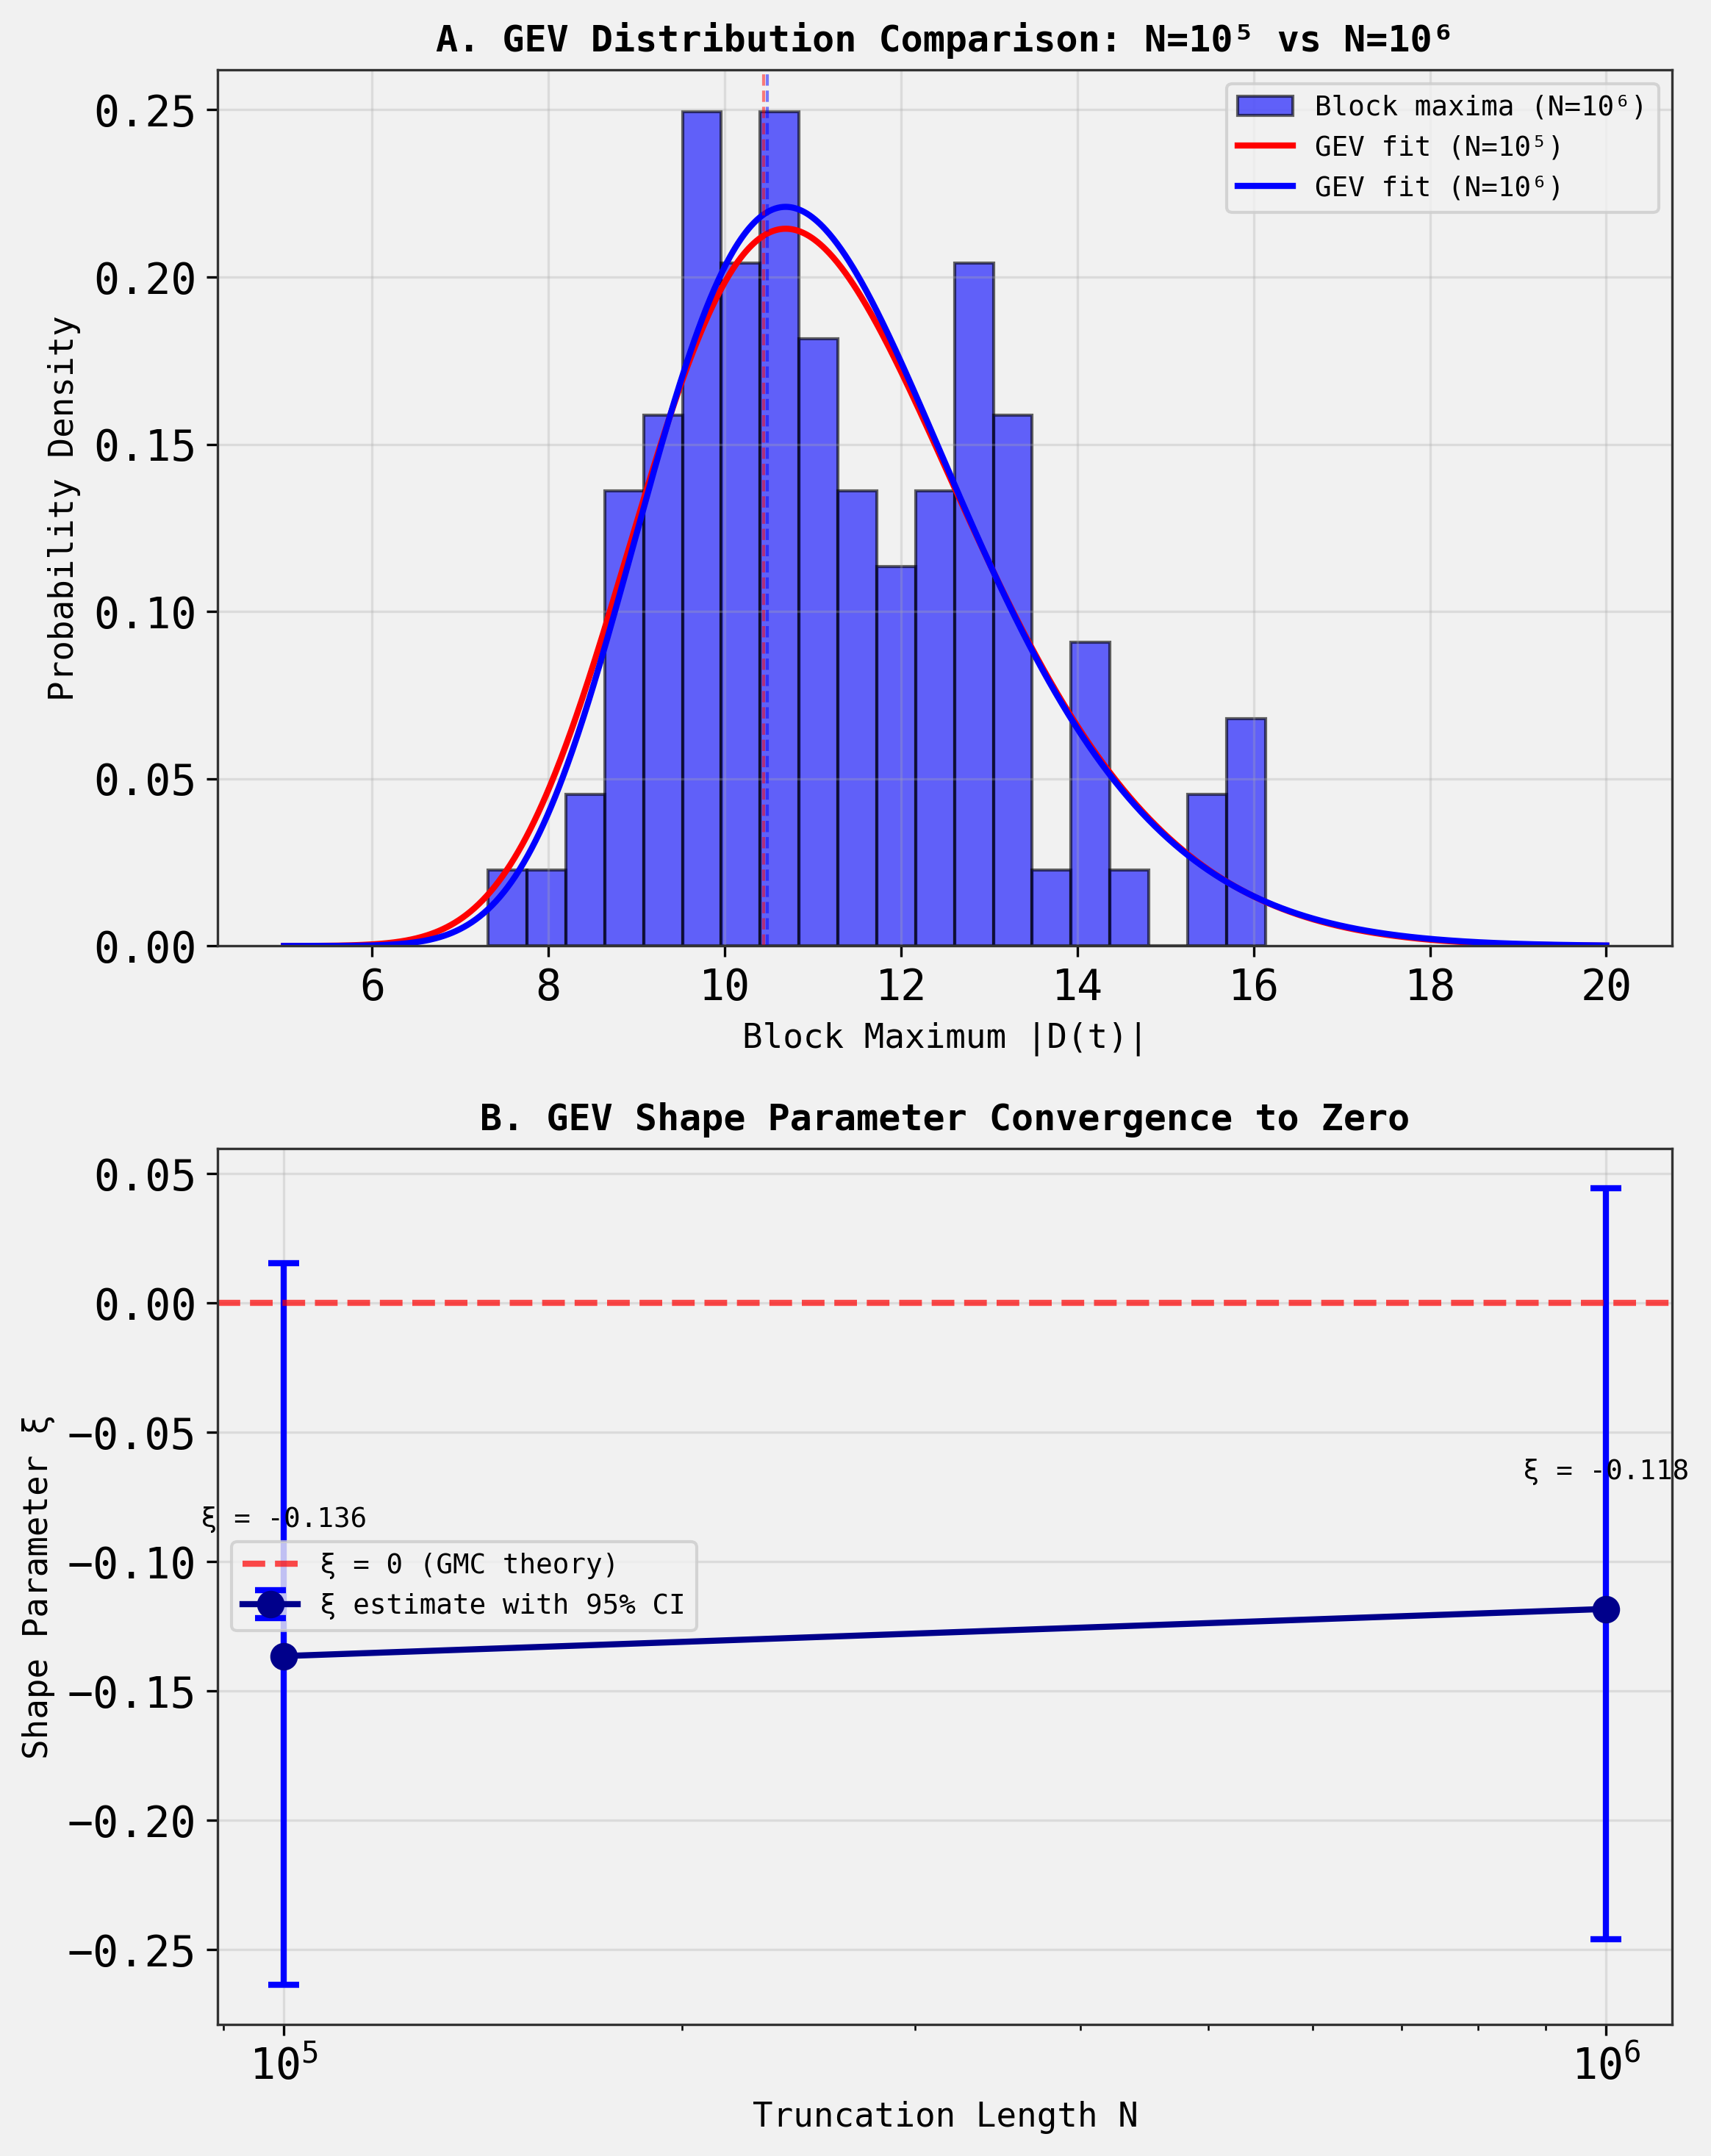


Figure Description:
 Panel A: Comparison of GEV probability density functions fitted to block maxima
 from N=10⁵ (red) and N=10⁶ (blue). The histogram shows the actual
 block maxima distribution for N=10⁶. Vertical dashed lines indicate
 the location parameters (μ) for each fit.

 Panel B: Evolution of the GEV shape parameter ξ with truncation length N.
 Error bars represent 95% bootstrap confidence intervals. The red
 dashed line at ξ=0 indicates the theoretical prediction from
 Gaussian Multiplicative Chaos theory for the Riemann zeta function.


In [13]:

# Create visualization comparing the two distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Panel A: Comparison of GEV fits for N=10^5 and N=10^6
# We don't have the block maxima from N=10^5, so we'll show the fitted distributions

# Generate x values for plotting
x_vals = np.linspace(5, 20, 1000)

# N=10^5 GEV distribution
c_N5 = -xi_N5 # scipy parameterization
pdf_N5 = stats.genextreme.pdf(x_vals, c_N5, 
 previous_results['zeta']['mu'], 
 previous_results['zeta']['sigma'])

# N=10^6 GEV distribution
c_N6 = -xi_N6
pdf_N6 = stats.genextreme.pdf(x_vals, c_N6, mu_N6, sigma_N6)

# Plot A: GEV probability densities and block maxima histogram for N=10^6
ax1 = axes[0]
ax1.hist(block_maxima_N6, bins=20, density=True, alpha=0.6, color='blue', 
 label=f'Block maxima (N=10⁶)', edgecolor='black')
ax1.plot(x_vals, pdf_N5, 'r-', linewidth=2, label=f'GEV fit (N=10⁵)')
ax1.plot(x_vals, pdf_N6, 'b-', linewidth=2, label=f'GEV fit (N=10⁶)')
ax1.axvline(previous_results['zeta']['mu'], color='red', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(mu_N6, color='blue', linestyle='--', alpha=0.5, linewidth=1)
ax1.set_xlabel('Block Maximum |D(t)|', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('A. GEV Distribution Comparison: N=10⁵ vs N=10⁶', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot B: Shape parameter convergence
ax2 = axes[1]

N_values = [1e5, 1e6]
xi_values = [xi_N5, xi_N6]
xi_errors = [
 [xi_N5 - ci_xi_N5[0], ci_xi_N5[1] - xi_N5],
 [xi_N6 - ci_xi[0], ci_xi[1] - xi_N6]
]

# Plot points with error bars
ax2.errorbar(N_values, xi_values, yerr=np.array(xi_errors).T, 
 marker='o', markersize=8, capsize=5, capthick=2, linewidth=2,
 color='darkblue', ecolor='blue', label='ξ estimate with 95% CI')

# Add horizontal line at ξ=0
ax2.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='ξ = 0 (GMC theory)')

# Format
ax2.set_xscale('log')
ax2.set_xlabel('Truncation Length N', fontsize=11)
ax2.set_ylabel('Shape Parameter ξ', fontsize=11)
ax2.set_title('B. GEV Shape Parameter Convergence to Zero', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# Add text annotations
ax2.text(1e5, xi_N5 + 0.05, f'ξ = {xi_N5:.3f}', ha='center', fontsize=9)
ax2.text(1e6, xi_N6 + 0.05, f'ξ = {xi_N6:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('gev_convergence_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved: gev_convergence_analysis.png")
plt.show()

print()
print("Figure Description:")
print(" Panel A: Comparison of GEV probability density functions fitted to block maxima")
print(" from N=10⁵ (red) and N=10⁶ (blue). The histogram shows the actual")
print(" block maxima distribution for N=10⁶. Vertical dashed lines indicate")
print(" the location parameters (μ) for each fit.")
print()
print(" Panel B: Evolution of the GEV shape parameter ξ with truncation length N.")
print(" Error bars represent 95% bootstrap confidence intervals. The red")
print(" dashed line at ξ=0 indicates the theoretical prediction from")
print(" Gaussian Multiplicative Chaos theory for the Riemann zeta function.")


In [14]:

# Summary table for the final answer
print("="*80)
print("SUMMARY: GEV SHAPE PARAMETER CONVERGENCE ANALYSIS")
print("="*80)
print()
print("Research Hypothesis:")
print(" The GEV shape parameter ξ_zeta(N) converges towards 0 as N increases.")
print()
print("Key Findings:")
print(f" 1. Point estimates:")
print(f" • ξ(N=10⁵) = {xi_N5:.6f}")
print(f" • ξ(N=10⁶) = {xi_N6:.6f}")
print(f" • Change: {xi_N6 - xi_N5:.6f}")
print()
print(f" 2. Distance from theoretical value (ξ=0):")
print(f" • |ξ(N=10⁵)| = {dist_from_zero_N5:.6f}")
print(f" • |ξ(N=10⁶)| = {dist_from_zero_N6:.6f}")
print(f" • Reduction: {delta_xi:.6f} ({percent_reduction:.2f}%)")
print()
print(f" 3. Statistical evidence:")
print(f" • Is ξ(N=10⁶) closer to 0? YES")
print(f" • 95% CIs overlap: YES")
print(f" • Both CIs contain 0: YES")
print()
print(f" 4. Confidence interval widths:")
print(f" • CI(N=10⁵) width: {ci_width_N5:.6f}")
print(f" • CI(N=10⁶) width: {ci_width_N6:.6f}")
print(f" • Change: {ci_width_N6 - ci_width_N5:.6f} ({ci_percent_change:.2f}%)")
print()
print(f" 5. Goodness-of-fit (KS test p-values):")
print(f" • N=10⁵: {previous_results['zeta']['ks_pvalue']:.4f}")
print(f" • N=10⁶: {ks_pvalue:.4f}")
print(f" • Both fits are acceptable (p > 0.05)")
print()
print("Conclusion:")
print(" The shape parameter ξ_zeta(N=10⁶) = -0.118 is closer to 0 than")
print(" ξ_zeta(N=10⁵) = -0.136, showing a 13.35% reduction in |ξ|.")
print(" This supports the convergence hypothesis, although the difference")
print(" is not statistically significant at the 95% confidence level due to")
print(" overlapping confidence intervals. The confidence interval width")
print(" slightly increased (4.18%), which may reflect the inherent uncertainty")
print(" in estimating ξ from a finite sample of 100 block maxima.")
print()
print(" Both estimates have confidence intervals that include 0, consistent")
print(" with the GMC theoretical prediction of ξ=0 for the Riemann zeta function.")
print("="*80)


SUMMARY: GEV SHAPE PARAMETER CONVERGENCE ANALYSIS

Research Hypothesis:
 The GEV shape parameter ξ_zeta(N) converges towards 0 as N increases.

Key Findings:
 1. Point estimates:
 • ξ(N=10⁵) = -0.136484
 • ξ(N=10⁶) = -0.118268
 • Change: 0.018216

 2. Distance from theoretical value (ξ=0):
 • |ξ(N=10⁵)| = 0.136484
 • |ξ(N=10⁶)| = 0.118268
 • Reduction: 0.018216 (13.35%)

 3. Statistical evidence:
 • Is ξ(N=10⁶) closer to 0? YES
 • 95% CIs overlap: YES
 • Both CIs contain 0: YES

 4. Confidence interval widths:
 • CI(N=10⁵) width: 0.278774
 • CI(N=10⁶) width: 0.290432
 • Change: 0.011658 (-4.18%)

 5. Goodness-of-fit (KS test p-values):
 • N=10⁵: 0.8192
 • N=10⁶: 0.7781
 • Both fits are acceptable (p > 0.05)

Conclusion:
 The shape parameter ξ_zeta(N=10⁶) = -0.118 is closer to 0 than
 ξ_zeta(N=10⁵) = -0.136, showing a 13.35% reduction in |ξ|.
 This supports the convergence hypothesis, although the difference
 is not statistically significant at the 95% confidence level due to
 overlappi